In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import sys

sys.path.append("./src")

# Load data

In [4]:
data=pd.read_csv("data/raw/data.csv")
data.head()

,Pat,AGE,SEX,EXAML,AMLSTAT,WBC,HB,PLT,LDH,BMB,...,t.6.11.,t.10.11.,t.11.19..q23.p13.,del.7q.,del.9q.,trisomy 8,trisomy 21,minus.Y,minus.X,Trial
0,R-S-072-137-GE6K,89,1,0.0,de novo,14.97,5.7753,22.0,834.0,78.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AMLReg
1,R-S-014-194-4X7E,86,0,0.0,sAML,45.00,4.2000,15.0,322.8,44.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AMLReg
2,R-S-010-054-NKCQ,85,0,0.0,de novo,193.22,7.0173,69.0,532.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AMLReg
3,R-S-030-143-C91F,85,1,0.0,de novo,1.36,4.0000,132.0,255.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AMLReg
4,R-S-068-082-K09I,85,1,0.0,de novo,49.40,6.5826,29.0,420.0,41.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AMLReg


# Synthetic data generation

In [5]:
from tabpfn_model import generate_synthetic_data_experiments

In [ ]:
synthetic_data, X_train, X_test= generate_synthetic_data_experiments(real_data=data_selected,
                                                                     n_synthetic_patients=10000,
                                                                     test_size= 0.25)
                                                                     

In [ ]:
# save the data
synthetic_data.to_csv("data/synthetic/Synthetic_Patients_10000.csv", index=False)
X_train.to_csv("data/synthetic/X_train.csv",  index=False)
X_test.to_csv("data/synthetic/X_test.csv",  index=False)

# Coxph Regression

In [6]:
from src.preprocessing import feature_selection
from src.helpers import infer_column_types
from src.coxph_model import coxph_model
from joblib import load, dump

**Feature selection for the modeling**

In [7]:
# Select features based on frequency on missing values ratio threshold
data_selected=feature_selection(data, positive_class_ratio=1, missing_values_ratio=50)

In [8]:
data_selected.head()

,AGE,WBC,HB,PLT,LDH,BMB,PBB,EFSTM,SEX,EXAML,...,del.5q.,minus.7,minus.17,t.v.11..v.q23.,del.7q.,del.9q.,trisomy 8,trisomy 21,minus.Y,minus.X
0,89,14.97,5.7753,22.0,834.0,78.0,84.0,0.854420,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,86,45.00,4.2000,15.0,322.8,44.0,14.0,0.131449,0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,85,193.22,7.0173,69.0,532.0,NaN,91.0,74.827473,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,85,1.36,4.0000,132.0,255.0,80.0,NaN,17.285573,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,85,49.40,6.5826,29.0,420.0,41.0,32.0,2.201775,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Run COXpropotional hazard model**

In [9]:
data_coxph, preprocessor=coxph_model(data_selected)

In [ ]:
# save preprocessor and cox_ph model data for future risk score matching
dump(preprocessor, "models/preprocessing/preprocessor.joblib")
data_coxph.to_csv("models/CoxPh/COX_coef.csv")

# Risk score matching

In [10]:
from src.riskscore_selection import selection_riskscore_based, range_based_filter

In [11]:
synthetic_df=pd.read_csv("data/synthetic/Synthetic_Patients_10000.csv")
X_train=pd.read_csv("data/synthetic/X_train_42.csv")
X_test=pd.read_csv("data/synthetic/X_test_42.csv")

In [13]:
synthetic_X_test, p=selection_riskscore_based(X_test, synthetic_df, cox_coef_path="models/CoxPh/COX_coef.csv", preprocessor_path="models/preprocessing/preprocessor.joblib")

In [14]:
synthetic_X_test.head()

,AGE,WBC,HB,PLT,LDH,BMB,PBB,EFSTM,SEX,EXAML,...,U2AF1,WT1,inv16_t16.16,t8.21,del.5q.,minus.7,minus.17,trisomy 8,trisomy 21,minus.Y
133,44,3.738939,6.664714,102.744560,200.34105,31.646408,25.458717,18.362722,0,0,...,0,0,0,0,0,0,0,1,0,0
1268,58,13.541535,5.711771,17.789272,439.43723,60.561028,85.514310,6.523303,1,0,...,0,0,0,0,0,0,0,0,0,0
7530,68,63.732807,6.213316,26.465755,665.38130,67.300410,24.961050,0.168916,0,0,...,0,0,0,0,0,0,0,0,0,0
8260,71,1.384553,6.010372,179.230590,163.37710,79.306270,21.374681,0.032815,1,0,...,0,0,0,0,1,0,1,0,0,0
4002,62,23.950900,4.580145,48.382760,572.72290,34.219727,5.254060,4.104898,0,0,...,0,0,0,0,0,0,1,0,0,0


In [15]:
p

0.8073368650711414

# Survival Analysis

In [16]:
from survival_metrics import kaplan_meier_curve,km_divergence, optimism_score, short_sightedness_score

<Axes: xlabel='Time in Months', ylabel='Survival probability'>

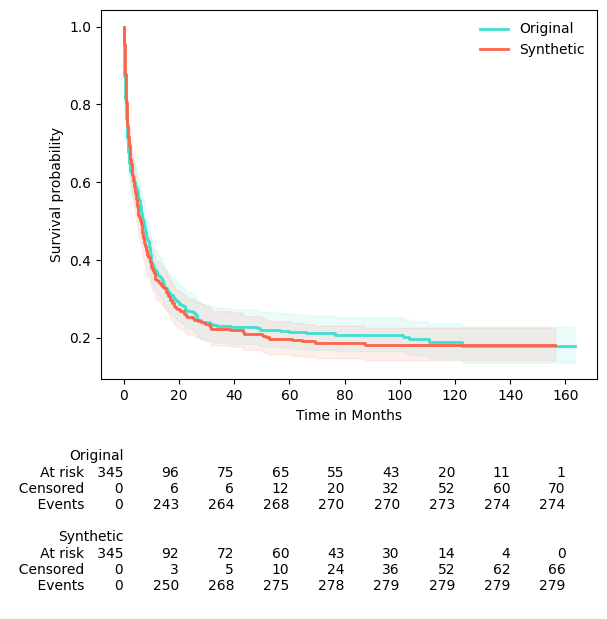

In [17]:
#kapkaplan_meier_curve
kaplan_meier_curve(X_test, synthetic_X_test, add_risk_counts=True)

In [19]:
print("KM divergence Score:", km_divergence (X_test, synthetic_X_test))
print("Optimisim Score:", optimism_score (X_test, synthetic_X_test))
print("Short sightedness Score:", short_sightedness_score (X_test, synthetic_X_test))


KM divergence Score: 0.013911694879371777
Optimisim Score: -0.010893043523900537
Short sightedness Score: 0.04276503470907737


# Fidelity Metrics

## Tabsyndex Metrics

In [20]:
from tabsyndex_metrics import tabsyndex

/Users/kakularamkumarreddy/.pyenv/versions/3.12.3/envs/synnext/lib/python3.12/site-packages/dython/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [21]:
continuous_columns, binary_columns = infer_column_types(X_test)

In [22]:
tabsyndex(X_test, synthetic_X_test, cat_cols=binary_columns, target_col="EFSTM")

{'score': 0.8138489302250276,
 'basic_score': 0.8778492174256572,
 'corr_score': 0.7039176108492864,
 'ml_score': 0.8066069464722971,
 'sup_score': 0.9031473892869957,
 'pmse_score': 0.7777234870909013}

## Synthcity Metrics

In [ ]:
# needed for synthcity compatibility
import torch
import torch.nn as nn


if not hasattr(nn, "RMSNorm"):
    # define a minimal RMSNorm (or import from torch.nn.functional)
    class RMSNorm(nn.Module):
        def __init__(self, normalized_shape, eps=1e-8, elementwise_affine=True):
            super().__init__()
            self.normalized_shape = normalized_shape
            self.eps = eps
            self.elementwise_affine = elementwise_affine
            if elementwise_affine:
                self.weight = nn.Parameter(torch.ones(normalized_shape))
                self.bias = nn.Parameter(torch.zeros(normalized_shape))
            else:
                self.register_parameter("weight", None)
                self.register_parameter("bias", None)

        def forward(self, x):
            # an approximate RMSNorm: x * (1 / sqrt(mean(x**2) + eps))
            norm = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
            y = x * norm
            if self.elementwise_affine:
                y = y * self.weight + self.bias
            return y

    nn.RMSNorm = RMSNorm

In [ ]:
from synthcity.metrics.eval import Metrics
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader

In [ ]:
X_gt= SurvivalAnalysisDataLoader(X_test,
    target_column="EFSSTAT",
    time_to_event_column="EFSTM")

X_syn= SurvivalAnalysisDataLoader(synthetic_X_test,
    target_column="EFSSTAT",
    time_to_event_column="EFSTM")
X_train= SurvivalAnalysisDataLoader(X_train,
    target_column="EFSSTAT",
    time_to_event_column="EFSTM")

In [ ]:
metrics_synthcity=Metrics().evaluate(X_gt=X_gt, X_syn=X_syn,X_train=X_train, task_type="survival_analysis")

In [ ]:
metrics_synthcity

# Stastical measure

In [23]:
from stastical_tests import fisher_exact_binary
from scipy.stats import mannwhitneyu

## Binary columns (fisher exact test)

In [24]:
fisher_exact_binary(X_test, synthetic_X_test, binary_columns)

,% Positive Real Data,% Positive Synthetic Data,p_value
trisomy 8,7.826,5.217,0.217
trisomy 21,1.739,3.188,0.326
t8.21,3.478,2.319,0.497
minus.Y,2.609,2.319,1.000
minus.7,4.928,4.928,1.000
minus.17,3.478,4.058,0.842
inv16_t16.16,6.957,4.928,0.334
del.5q.,4.928,5.507,0.864
WT1,6.667,3.768,0.122
U2AF1,2.609,2.609,1.000


In [25]:

for col in continuous_columns:
    print(f"*******************\n{col}\n*******************")
    print("Mann-Whitney U rank test p value :" ,np.round(mannwhitneyu( X_test[col],synthetic_X_test[col]).pvalue,3))
    print("\n")

*******************
AGE
*******************
Mann-Whitney U rank test p value : 0.538


*******************
WBC
*******************
Mann-Whitney U rank test p value : 0.966


*******************
HB
*******************
Mann-Whitney U rank test p value : 0.954


*******************
PLT
*******************
Mann-Whitney U rank test p value : 0.017


*******************
LDH
*******************
Mann-Whitney U rank test p value : 0.233


*******************
BMB
*******************
Mann-Whitney U rank test p value : 0.895


*******************
PBB
*******************
Mann-Whitney U rank test p value : 0.832


*******************
EFSTM
*******************
Mann-Whitney U rank test p value : 0.852




# Privacy metrics

In [26]:
from privacy_metrics import *

In [27]:
real_data=X_train.copy()
synthetic_data=range_based_filter(real_data, synthetic_df)
synthetic_data[binary_columns]=synthetic_data[binary_columns].astype("int")

In [28]:
print("Exact Matches: ",exact_match_count(real_data, synthetic_data))

Exact Matches:  0


In [29]:
print("Median Distance to Closest Recard: ",dcr_euclidean(real_data, synthetic_data))

Median Distance to Closest Recard:  1.9448235897885935


In [30]:
print("Median Nearest Neighbour Distance Ratio: ",nndr_euclidean( real_data, synthetic_data))

Median Nearest Neighbour Distance Ratio:  0.9416529692284377


In [31]:
print("Membership Inference attack")
membership_inference_attack(real_data, synthetic_data, X_test)

Membership Inference attack


,roc_auc,accuracy
0,0.557196,0.524328
